In [10]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
print('All libraries imported successfully!')

All libraries imported successfully!


In [11]:
TICKERS  = ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'TSLA']
START    = '2020-01-01'
END      = '2024-12-31'
MAIN     = 'AAPL'
print('Downloading stock data')
raw = yf.download(TICKERS, start=START, end=END, auto_adjust=True)
close   = raw['Close']
returns = close.pct_change().dropna()
df = raw.xs(MAIN, axis=1, level=1).copy()
df.columns.name = None
df.dropna(inplace=True)

print(f' Downloaded {len(df)} rows for {MAIN}')
print(f'   Columns: {list(df.columns)}')
df.head()

[                       0%                       ]

[*********************100%***********************]  5 of 5 completed


 Downloaded 1257 rows for AAPL
   Columns: ['Close', 'High', 'Low', 'Open', 'Volume']


,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.333870,72.394078,71.091176,71.344047,135480400
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200
2020-01-07,71.861832,72.466315,71.642674,72.211033,108872000
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200


In [12]:
def add_technical_indicators(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()

    for w in [7, 21, 50, 200]:
        d[f'SMA_{w}']  = d['Close'].rolling(w).mean()
        d[f'EMA_{w}']  = d['Close'].ewm(span=w, adjust=False).mean()
    bb_mid            = d['Close'].rolling(20).mean()
    bb_std            = d['Close'].rolling(20).std()
    d['BB_Upper']     = bb_mid + 2 * bb_std
    d['BB_Lower']     = bb_mid - 2 * bb_std
    d['BB_Middle']    = bb_mid
    d['BB_Width']     = (d['BB_Upper'] - d['BB_Lower']) / bb_mid

    # ── RSI (14) ─────────────────────────────────────────────────────────────────
    delta  = d['Close'].diff()
    gain   = delta.clip(lower=0).rolling(14).mean()
    loss   = (-delta.clip(upper=0)).rolling(14).mean()
    rs     = gain / loss.replace(0, np.nan)
    d['RSI'] = 100 - (100 / (1 + rs))
    ema12        = d['Close'].ewm(span=12, adjust=False).mean()
    ema26        = d['Close'].ewm(span=26, adjust=False).mean()
    d['MACD']    = ema12 - ema26
    d['MACD_Signal'] = d['MACD'].ewm(span=9, adjust=False).mean()
    d['MACD_Hist']   = d['MACD'] - d['MACD_Signal']
    d['Volume_MA20']  = d['Volume'].rolling(20).mean()
    d['Volume_Ratio'] = d['Volume'] / d['Volume_MA20']
    h_l  = d['High'] - d['Low']
    h_cp = (d['High'] - d['Close'].shift()).abs()
    l_cp = (d['Low']  - d['Close'].shift()).abs()
    tr   = pd.concat([h_l, h_cp, l_cp], axis=1).max(axis=1)
    d['ATR'] = tr.rolling(14).mean()
    d['Return_1d'] = d['Close'].pct_change(1)
    d['Return_5d'] = d['Close'].pct_change(5)
    d['Return_21d']= d['Close'].pct_change(21)
    for lag in [1, 2, 3, 5, 10]:
        d[f'Lag_{lag}'] = d['Close'].shift(lag)

    d['Target']       = (d['Close'].shift(-1) > d['Close']).astype(int)
    d['Target_Return']= d['Close'].shift(-1) / d['Close'] - 1

    return d.dropna()
df = add_technical_indicators(df)
print(f'Feature engineering complete – {df.shape[1]} columns, {df.shape[0]} rows')
df.head(3)

Feature engineering complete – 34 columns, 1057 rows


,Close,High,Low,Open,Volume,SMA_7,EMA_7,SMA_21,EMA_21,SMA_50,...,Return_1d,Return_5d,Return_21d,Lag_1,Lag_2,Lag_3,Lag_5,Lag_10,Target,Target_Return
Date,,,,,,,,,,,,,,,,,,,,,
2020-10-15,117.085510,117.560795,114.602380,115.155265,112559200,115.623630,115.893782,111.105398,113.309902,113.408251,...,-0.003961,0.049926,0.076518,117.551117,117.463799,120.664711,111.517868,113.283211,0,-0.014001
2020-10-16,115.446251,117.900290,115.242557,117.638393,115393800,116.169583,115.781899,111.506321,113.504115,113.511504,...,-0.014001,0.017526,0.078666,117.085510,117.551117,117.463799,113.457825,109.626427,0,-0.025542
2020-10-19,112.497551,116.804229,112.187160,116.358042,120639300,116.309538,114.960812,111.928491,113.412609,113.605931,...,-0.025542,-0.067685,0.085549,115.446251,117.085510,117.551117,120.664711,113.001930,1,0.013192


In [14]:
recent = df.tail(252)

fig = make_subplots(rows=3, cols=1, shared_xaxes=True, row_heights=[0.6, 0.2, 0.2],
                    subplot_titles=[f'{MAIN} Price + Bollinger Bands', 'Volume', 'RSI'])

fig.add_trace(go.Candlestick(x=recent.index, open=recent['Open'],
                              high=recent['High'], low=recent['Low'], close=recent['Close'],
                              name='OHLC'), row=1, col=1)

for band, color in [('BB_Upper','rgba(255,100,100,0.3)'),
                    ('BB_Middle','rgba(100,100,255,0.5)'),
                    ('BB_Lower','rgba(100,200,100,0.3)')]:
    fig.add_trace(go.Scatter(x=recent.index, y=recent[band],
                             name=band, line=dict(color=color, width=1)), row=1, col=1)

colors = ['green' if r >= 0 else 'red' for r in recent['Return_1d']]
fig.add_trace(go.Bar(x=recent.index, y=recent['Volume'], name='Volume',
                     marker_color=colors), row=2, col=1)

fig.add_trace(go.Scatter(x=recent.index, y=recent['RSI'], name='RSI',
                         line=dict(color='purple', width=1.5)), row=3, col=1)
for level, color in [(70,'red'), (30,'green')]:
    fig.add_hline(y=level, line_color=color, line_dash='dash', row=3, col=1)

fig.update_layout(height=800, title_text=f'{MAIN} Technical Analysis Dashboard',
                  xaxis_rangeslider_visible=False, template='plotly_dark')
fig.show()

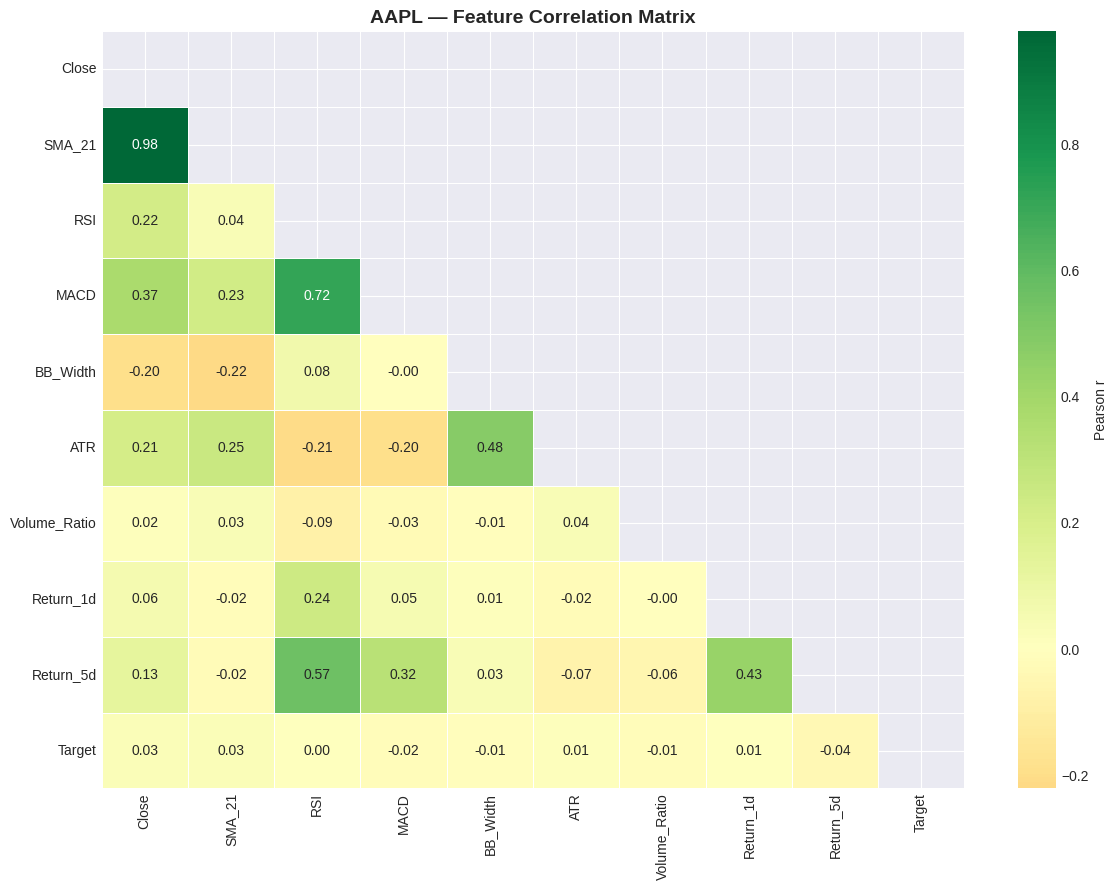

In [15]:
corr_cols = ['Close','SMA_21','RSI','MACD','BB_Width','ATR',
             'Volume_Ratio','Return_1d','Return_5d','Target']

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(df[corr_cols].corr(), dtype=bool))
sns.heatmap(df[corr_cols].corr(), mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            cbar_kws={'label': 'Pearson r'})
plt.title(f'{MAIN} — Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
normalised = close / close.iloc[0] * 100

fig = px.line(normalised, title='Normalised Price Performance (Base=100)',
              labels={'value': 'Normalised Price', 'variable': 'Ticker'},
              template='plotly_dark')
fig.update_layout(hovermode='x unified', height=500)
fig.show()

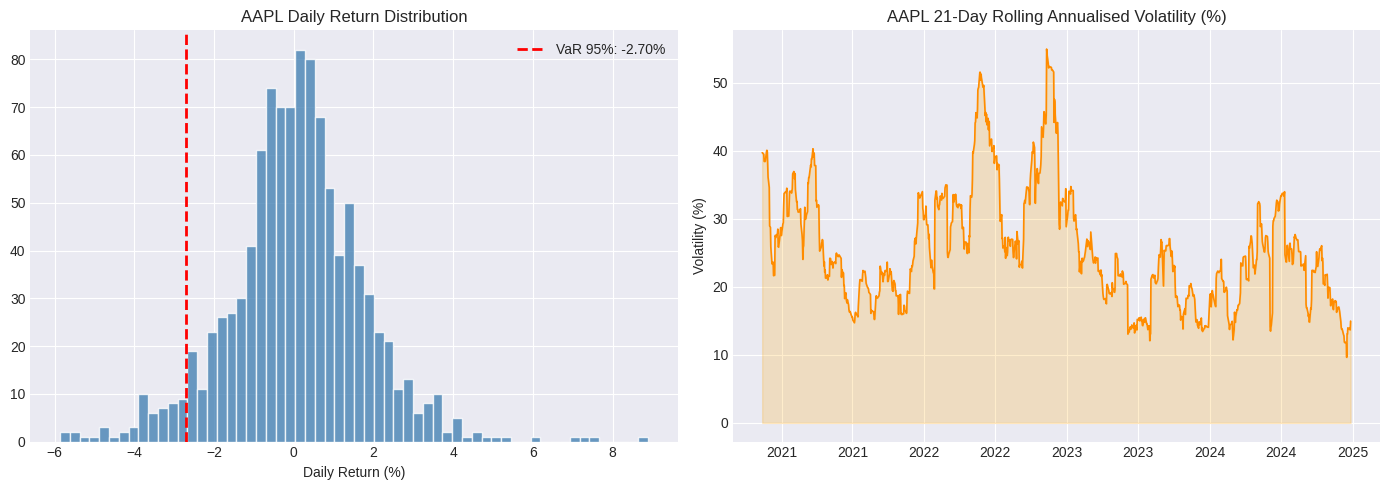

Annualised Volatility (full period): 26.9%
95% VaR (daily):  -2.70%
99% VaR (daily):  -4.20%


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

r = df['Return_1d'].dropna() * 100
axes[0].hist(r, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
var95 = np.percentile(r, 5)
axes[0].axvline(var95, color='red', linestyle='--', linewidth=2,
                label=f'VaR 95%: {var95:.2f}%')
axes[0].set_title(f'{MAIN} Daily Return Distribution')
axes[0].set_xlabel('Daily Return (%)')
axes[0].legend()
roll_vol = df['Return_1d'].rolling(21).std() * np.sqrt(252) * 100
axes[1].plot(roll_vol.index, roll_vol, color='darkorange', linewidth=1.2)
axes[1].fill_between(roll_vol.index, roll_vol, alpha=0.2, color='orange')
axes[1].set_title(f'{MAIN} 21-Day Rolling Annualised Volatility (%)')
axes[1].set_ylabel('Volatility (%)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()
print(f'Annualised Volatility (full period): {r.std()*np.sqrt(252):.1f}%')
print(f'95% VaR (daily):  {var95:.2f}%')
print(f'99% VaR (daily):  {np.percentile(r,1):.2f}%')

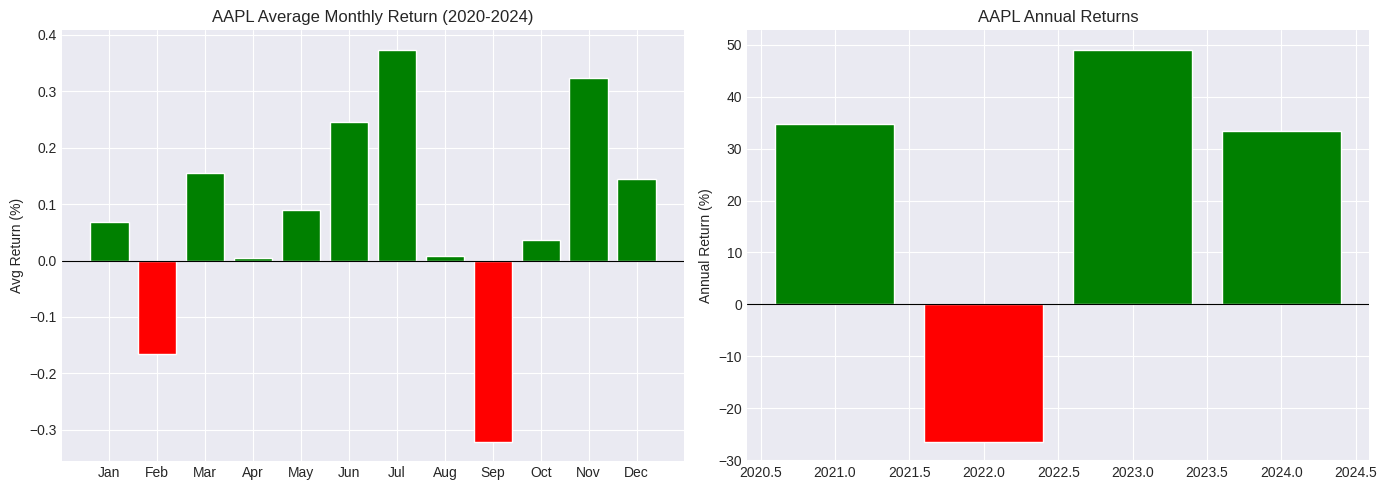

In [18]:
monthly = df['Return_1d'].resample('ME').sum() * 100
monthly_pivot = pd.DataFrame({'Return': monthly, 'Year': monthly.index.year,
                               'Month': monthly.index.month_name()})

avg_monthly = df['Return_1d'].groupby(df.index.month).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
colors = ['green' if x >= 0 else 'red' for x in avg_monthly.values]
axes[0].bar(month_names, avg_monthly.values, color=colors, edgecolor='white')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title(f'{MAIN} Average Monthly Return (2020-2024)')
axes[0].set_ylabel('Avg Return (%)')

year_return = df['Close'].resample('YE').last().pct_change() * 100
year_colors = ['green' if x >= 0 else 'red' for x in year_return.dropna()]
axes[1].bar(year_return.dropna().index.year, year_return.dropna().values,
            color=year_colors, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title(f'{MAIN} Annual Returns')
axes[1].set_ylabel('Annual Return (%)')

plt.tight_layout()
plt.show()

In [19]:
df.to_csv('stock_features.csv')
close.to_csv('close_prices.csv')
returns.to_csv('daily_returns.csv')
print(' Data saved to CSV – ready for Notebook 2 (ML Models)')

 Data saved to CSV – ready for Notebook 2 (ML Models)


In [20]:
print('=' * 55)
print(f'  {MAIN} Statistical Summary ({START} to {END})')
print('=' * 55)
latest = df['Close'].iloc[-1]
start_p = df['Close'].iloc[0]
total_ret = (latest - start_p) / start_p * 100
cagr = ((latest / start_p) ** (1/4) - 1) * 100
metrics = {
    'Starting Price':   f'${start_p:.2f}',
    'Latest Price':     f'${latest:.2f}',
    'Total Return':     f'{total_ret:.1f}%',
    'CAGR (4yr)':       f'{cagr:.1f}%',
    'Ann. Volatility':  f'{df["Return_1d"].std()*np.sqrt(252)*100:.1f}%',
    'Sharpe Ratio':     f'{(df["Return_1d"].mean()*252)/(df["Return_1d"].std()*np.sqrt(252)):.2f}',
    'Max Drawdown':     f'{((df["Close"]/df["Close"].cummax()-1).min()*100):.1f}%',
    'Avg Daily Volume': f'{df["Volume"].mean()/1e6:.1f}M',
    'Target=1 (Up days)':f'{df["Target"].mean()*100:.1f}%',
}
for k, v in metrics.items():
    print(f'  {k:<22} {v:>12}')
print('=' * 55)

  AAPL Statistical Summary (2020-01-01 to 2024-12-31)
  Starting Price              $117.09
  Latest Price                $253.97
  Total Return                 116.9%
  CAGR (4yr)                    21.4%
  Ann. Volatility               26.9%
  Sharpe Ratio                   0.82
  Max Drawdown                 -30.9%
  Avg Daily Volume              75.6M
  Target=1 (Up days)            53.0%
